# HyperParam Experiment

用于在同一套 `（5个循环 + 1个RPT） * 14` 协议下，给定不同 PyBaMM 超参数，生成不同退化曲线并比较结果。

In [1]:
from pathlib import Path
import json
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "src").exists() and (candidate / "configs").exists():
            return candidate
    raise FileNotFoundError("Cannot locate project root from current working directory")

ROOT = find_project_root(Path.cwd().resolve())
OUT_DIR = ROOT / "notebooks" / "experiment"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR


PosixPath('/home/netszx/AlphaB/notebooks/experiment')

In [2]:
# ===== 协议配置 =====
BLOCKS = 14
CYCLES_PER_CHECKPOINT = 5
DISCHARGE_C_RATE = 1.0
CHARGE_STAGE_1_C_RATE = 1.5
CHARGE_STAGE_2_C_RATE = 0.8
CV_VOLTAGE = 4.2
CV_CUTOFF = "C/100"
LOW_VOLTAGE_CUTOFF = 2.5
PERIOD = "1 minute"
SOC_STAGE_1 = 0.30
SOC_STAGE_2 = 0.50

RPT = [
    "Rest for 30 minutes",
    "Discharge at 0.1C until 2.5 V",
    "Rest for 30 minutes",
    "Charge at 0.1C until 4.2 V",
    "Hold at 4.2 V until C/100",
    "Rest for 60 minutes",
    "Discharge at 1C for 10 seconds",
    "Rest for 10 minutes",
    "Charge at 1C for 10 seconds",
    "Rest for 10 minutes",
    "Discharge at C/5 for 60 minutes",
    "Rest for 60 minutes",
    "Discharge at 1C for 10 seconds",
    "Rest for 10 minutes",
    "Charge at 1C for 10 seconds",
    "Rest for 10 minutes",
    "Discharge at C/5 for 90 minutes",
    "Rest for 60 minutes",
    "Discharge at 1C for 10 seconds",
    "Rest for 10 minutes",
    "Charge at 1C for 10 seconds",
    "Rest for 10 minutes",
    "Discharge at C/5 for 90 minutes",
    "Rest for 60 minutes",
    "Discharge at 1C for 10 seconds",
    "Rest for 10 minutes",
    "Charge at 1C for 10 seconds",
    "Rest for 10 minutes",
]

In [3]:
def soc_delta_to_hours(soc_delta: float, c_rate: float) -> float:
    if c_rate <= 0:
        raise ValueError("C-rate must be positive")
    return soc_delta / c_rate

stage1_hours = soc_delta_to_hours(SOC_STAGE_1, CHARGE_STAGE_1_C_RATE)
stage2_hours = soc_delta_to_hours(SOC_STAGE_2, CHARGE_STAGE_2_C_RATE)
ageing_cycle_steps = [
    f"Discharge at {DISCHARGE_C_RATE}C until {LOW_VOLTAGE_CUTOFF} V",
    f"Charge at {CHARGE_STAGE_1_C_RATE}C for {stage1_hours:.6f} hours",
    f"Charge at {CHARGE_STAGE_2_C_RATE}C for {stage2_hours:.6f} hours",
    f"Hold at {CV_VOLTAGE} V until {CV_CUTOFF}",
]
rpt_steps = RPT
rpt_extractors = {
    "capacity_step_index": 1,
    "dcir_rest_step_index": 5,
    "dcir_pulse_step_index": 6,
    "hppc_pulse_step_index": 6,
    "low_rate_discharge_step_index": 1,
    "low_rate_charge_step_index": 3,
    "pulse_pairs": [
        {"label": "100_soc", "rest_step_index": 5,  "discharge_pulse_step_index": 6,  "charge_pulse_step_index": 8},
        {"label": "80_soc",  "rest_step_index": 11, "discharge_pulse_step_index": 12, "charge_pulse_step_index": 14},
        {"label": "50_soc",  "rest_step_index": 17, "discharge_pulse_step_index": 18, "charge_pulse_step_index": 20},
        {"label": "20_soc",  "rest_step_index": 23, "discharge_pulse_step_index": 24, "charge_pulse_step_index": 26},
    ],
}
protocol = {
    "period": PERIOD,
    "cycles_per_checkpoint": CYCLES_PER_CHECKPOINT,
    "n_checkpoints": BLOCKS,
    "ageing_cycle_steps": ageing_cycle_steps,
    "rpt_steps": rpt_steps,
    "rpt_extractors": rpt_extractors,
}
protocol_path = OUT_DIR / "protocol_5cycles_1rpt_14blocks.json"
protocol_path.write_text(json.dumps(protocol, ensure_ascii=False, indent=2), encoding="utf-8")
rows = []
for checkpoint in range(1, BLOCKS + 1):
    for step_index, instruction in enumerate(ageing_cycle_steps, start=1):
        rows.append({
            "segment_id": checkpoint,
            "checkpoint": checkpoint,
            "repeat_count": CYCLES_PER_CHECKPOINT,
            "step_index": step_index,
            "instruction": instruction,
        })
cycle_protocols = pd.DataFrame(rows)
cycle_protocols_path = OUT_DIR / "cycle_protocols_5cycles_1rpt_14blocks.csv"
cycle_protocols.to_csv(cycle_protocols_path, index=False)
cycle_protocols.head(12)

,segment_id,checkpoint,repeat_count,step_index,instruction
0,1,1,5,1,Discharge at 1.0C until 2.5 V
1,1,1,5,2,Charge at 1.5C for 0.200000 hours
2,1,1,5,3,Charge at 0.8C for 0.625000 hours
3,1,1,5,4,Hold at 4.2 V until C/100
4,2,2,5,1,Discharge at 1.0C until 2.5 V
5,2,2,5,2,Charge at 1.5C for 0.200000 hours
6,2,2,5,3,Charge at 0.8C for 0.625000 hours
7,2,2,5,4,Hold at 4.2 V until C/100
8,3,3,5,1,Discharge at 1.0C until 2.5 V
9,3,3,5,2,Charge at 1.5C for 0.200000 hours


In [4]:
CALIBRATION_MAP = ROOT / "configs" / "calibration_map.json"
BASE_OVERRIDES_PATH = ROOT / "configs" / "model_parameter_overrides.json"
with CALIBRATION_MAP.open("r", encoding="utf-8") as f:
    calibration_spec = json.load(f)
with BASE_OVERRIDES_PATH.open("r", encoding="utf-8") as f:
    base_overrides = json.load(f)
def bounds_to_text(spec):
    lo, hi = spec["bounds"]
    if spec.get("transform") == "log10":
        return f"1e{lo:g} ~ 1e{hi:g}"
    return f"{lo:g} ~ {hi:g}"
def bounds_numeric(spec):
    lo, hi = spec["bounds"]
    if spec.get("transform") == "log10":
        return 10 ** lo, 10 ** hi
    return lo, hi
range_rows = []
for spec in calibration_spec:
    lo_num, hi_num = bounds_numeric(spec)
    range_rows.append({
        "name": spec["name"],
        "kind": spec.get("kind", "parameter"),
        "transform": spec.get("transform", "linear"),
        "bounds_raw": spec["bounds"],
        "bounds_physical": bounds_to_text(spec),
        "lower_numeric": lo_num,
        "upper_numeric": hi_num,
        "targets": ", ".join(spec.get("targets", [])),
    })
range_df = pd.DataFrame(range_rows)
range_df

,name,kind,transform,bounds_raw,bounds_physical,lower_numeric,upper_numeric,targets
0,sei_solvent_diffusivity,parameter,log10,"[-24.0, -18.0]",1e-24 ~ 1e-18,1.000000e-24,1.000000e-18,Outer SEI solvent diffusivity [m2.s-1]
1,plating_rate_constant,parameter,log10,"[-12.0, -7.0]",1e-12 ~ 1e-7,1.000000e-12,1.000000e-07,Lithium plating kinetic rate constant [m.s-1]
2,negative_lam_rate,parameter,log10,"[-14.0, -8.0]",1e-14 ~ 1e-8,1.000000e-14,1.000000e-08,Negative electrode LAM constant proportional t...
3,negative_critical_stress,parameter,log10,"[6.0, 9.0]",1e6 ~ 1e9,1.000000e+06,1.000000e+09,Negative electrode critical stress [Pa]
4,dryout_scale,dryout_scale,linear,"[0.7, 1.0]",0.7 ~ 1,7.000000e-01,1.000000e+00,


In [5]:
# ===== 自定义超参数组合 =====
HYPERPARAM_CASES = {
    "baseline": {},
    #"sei_fast": {"sei_solvent_diffusivity": 1e-19,},
    #"plating_lam_aggressive": { "plating_rate_constant": 5e-9,"negative_lam_rate": 5e-10,"negative_critical_stress": 5e7, "dryout_scale": 0.85,},
}
HYPERPARAM_CASES

{'baseline': {}}

In [6]:
spec_by_name = {spec["name"]: spec for spec in calibration_spec}
def validate_case(case_name, case_values):
    for key, value in case_values.items():
        if key not in spec_by_name:
            raise KeyError(f"{case_name}: 未知超参数 {key}")
        spec = spec_by_name[key]
        lo_num, hi_num = bounds_numeric(spec)
        if not (lo_num <= value <= hi_num):
            raise ValueError(f"{case_name}: {key}={value} 超出范围 [{lo_num}, {hi_num}]")
for case_name, case_values in HYPERPARAM_CASES.items():
    validate_case(case_name, case_values)
pd.DataFrame([{"case": case_name, **case_values} for case_name, case_values in HYPERPARAM_CASES.items()]).fillna("")

,case
0,baseline


In [7]:
def build_case_inputs(case_name, case_values):
    overrides = dict(base_overrides)
    dryout_scale = None
    for key, value in case_values.items():
        spec = spec_by_name[key]
        if spec.get("kind") == "dryout_scale":
            dryout_scale = value
        else:
            for target in spec.get("targets", []):
                overrides[target] = value
    overrides_path = OUT_DIR / f"parameter_overrides_{case_name}.json"
    overrides_path.write_text(json.dumps(overrides, ensure_ascii=False, indent=2), encoding="utf-8")
    dryout_arg = []
    if dryout_scale is not None:
        dryout_arg = ["--dryout-scale", str(dryout_scale)]
    return overrides_path, dryout_arg

case_commands = {}
for case_name, case_values in HYPERPARAM_CASES.items():
    overrides_path, dryout_arg = build_case_inputs(case_name, case_values)
    case_dir = OUT_DIR / case_name
    case_dir.mkdir(parents=True, exist_ok=True)
    cmd = [
        "python", "src/degradation/coupled_degradation_model.py",
        "--protocol-json", str(protocol_path),
        "--cycle-protocol-csv", str(cycle_protocols_path),
        "--parameter-overrides-json", str(overrides_path),
        "--output-csv", str(case_dir / "coupled_summary.csv"),
        "--output-trace-csv", str(case_dir / "coupled_rpt_traces.csv"),
        "--output-feature-csv", str(case_dir / "coupled_rpt_features.csv"),
        "--output-state-json", str(case_dir / "coupled_state.json"),
    ] + dryout_arg
    case_commands[case_name] = cmd
for case_name, cmd in case_commands.items():
    print(case_name)
    print(" ".join(cmd))
    print()

baseline
python src/degradation/coupled_degradation_model.py --protocol-json /home/netszx/AlphaB/notebooks/experiment/protocol_5cycles_1rpt_14blocks.json --cycle-protocol-csv /home/netszx/AlphaB/notebooks/experiment/cycle_protocols_5cycles_1rpt_14blocks.csv --parameter-overrides-json /home/netszx/AlphaB/notebooks/experiment/parameter_overrides_baseline.json --output-csv /home/netszx/AlphaB/notebooks/experiment/baseline/coupled_summary.csv --output-trace-csv /home/netszx/AlphaB/notebooks/experiment/baseline/coupled_rpt_traces.csv --output-feature-csv /home/netszx/AlphaB/notebooks/experiment/baseline/coupled_rpt_features.csv --output-state-json /home/netszx/AlphaB/notebooks/experiment/baseline/coupled_state.json



In [8]:
# 批量运行所有超参数组合
for case_name, cmd in case_commands.items():
    print(f"Running case: {case_name}")
    subprocess.run(cmd, cwd=ROOT, check=True)

Running case: baseline


/home/netszx/miniforge/envs/ai4b/lib/python3.9/site-packages/pybamm/util.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
At t = 526.704 and h = 1.1843e-11, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 462.318 and h = 1.60214e-11, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 222.318 and h = 1.86492e-11, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 461.462 and h = 5.13091e-12, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 166.872 and h = 6.70137e-10, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 460.733 and h = 1.43803e-14, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 220.736 and h = 1.70281e-11, the corrector conver

Saved degradation summary: /home/netszx/AlphaB/notebooks/experiment/baseline/coupled_summary.csv
Saved RPT traces: /home/netszx/AlphaB/notebooks/experiment/baseline/coupled_rpt_traces.csv
Saved RPT features: /home/netszx/AlphaB/notebooks/experiment/baseline/coupled_rpt_features.csv
Saved final state: /home/netszx/AlphaB/notebooks/experiment/baseline/coupled_state.json
 checkpoint  cycle  capacity_01c_ah  dcir_ohm  hppc_power_w  throughput_ah  lli_pct  lam_ne_pct  lam_pe_pct  neg_porosity  voltage_v  dcir_100_soc_ohm  hppc_discharge_power_100_soc_w  hppc_charge_power_100_soc_w  dcir_80_soc_ohm  hppc_discharge_power_80_soc_w  hppc_charge_power_80_soc_w  dcir_50_soc_ohm  hppc_discharge_power_50_soc_w  hppc_charge_power_50_soc_w  dcir_20_soc_ohm  hppc_discharge_power_20_soc_w  hppc_charge_power_20_soc_w  dqdv_peak_v_discharge  dqdv_peak_h_discharge  ica_area_discharge  dqdv_peak_v_charge  dqdv_peak_h_charge  ica_area_charge    soh_pct
          1      5         5.078626  0.032384     21.79

In [9]:
case_summaries = []
for case_name in HYPERPARAM_CASES:
    case_summary_path = OUT_DIR / case_name / "coupled_summary.csv"
    if case_summary_path.exists():
        df = pd.read_csv(case_summary_path).sort_values("checkpoint").reset_index(drop=True)
        if "soh_pct" not in df.columns:
            df["soh_pct"] = 100 * df["capacity_01c_ah"] / df["capacity_01c_ah"].iloc[0]
        df["case"] = case_name
        case_summaries.append(df)
multi_case_summary = pd.concat(case_summaries, ignore_index=True)
multi_case_summary.head()

,checkpoint,cycle,capacity_01c_ah,dcir_ohm,hppc_power_w,throughput_ah,lli_pct,lam_ne_pct,lam_pe_pct,neg_porosity,...,hppc_discharge_power_20_soc_w,hppc_charge_power_20_soc_w,dqdv_peak_v_discharge,dqdv_peak_h_discharge,ica_area_discharge,dqdv_peak_v_charge,dqdv_peak_h_charge,ica_area_charge,soh_pct,case
0,1,5,5.078626,0.032384,21.790610,64.407366,0.153034,0.003553,0.001898,0.245568,...,16.811129,18.199138,4.075032,-20.229766,5.078626,4.118885,-17.811832,5.016000,100.000000,baseline
1,2,10,5.072394,0.032417,21.792853,60.281866,0.227530,0.006698,0.003797,0.243499,...,16.809916,18.201429,4.075113,-20.341617,5.072394,4.118892,-17.912565,5.009789,99.877301,baseline
2,3,15,5.067953,0.032453,21.794886,60.221839,0.287327,0.009839,0.005690,0.241857,...,16.806346,18.204167,4.075230,-20.399938,5.067953,4.118896,-18.055572,5.005230,99.789844,baseline
3,4,20,5.064412,0.032491,21.796682,60.175359,0.338998,0.012978,0.007578,0.240450,...,16.803320,18.206634,4.075358,-20.369230,5.064412,4.118899,-18.163784,5.001512,99.720132,baseline
4,5,25,5.061356,0.032529,21.798174,60.135572,0.385289,0.016116,0.009463,0.239198,...,16.801363,18.208239,4.075483,-20.206213,5.061356,4.118902,-18.242253,4.998294,99.659947,baseline


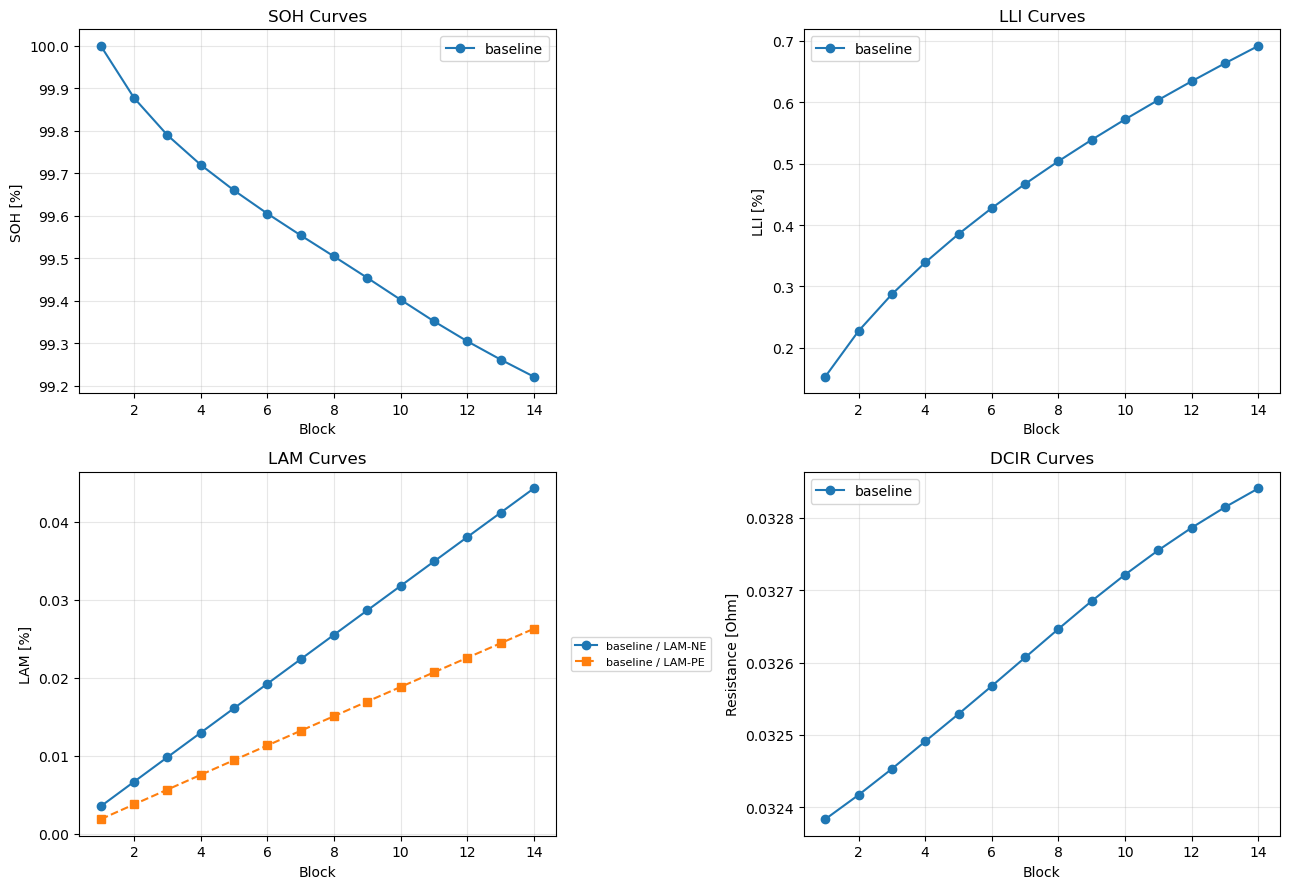

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for case_name, group in multi_case_summary.groupby("case"):
    x = group["checkpoint"]
    axes[0, 0].plot(x, group["soh_pct"], "o-", label=case_name)
    axes[0, 1].plot(x, group["lli_pct"], "o-", label=case_name)
    axes[1, 0].plot(x, group["lam_ne_pct"], "o-", label=f"{case_name} / LAM-NE")
    axes[1, 0].plot(x, group["lam_pe_pct"], "s--", label=f"{case_name} / LAM-PE")
    dcir_col = "dcir_100_soc_ohm" if "dcir_100_soc_ohm" in group.columns else "dcir_ohm"
    axes[1, 1].plot(x, group[dcir_col], "o-", label=case_name)
axes[0, 0].set_title("SOH Curves")
axes[0, 0].set_xlabel("Block")
axes[0, 0].set_ylabel("SOH [%]")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()
axes[0, 1].set_title("LLI Curves")
axes[0, 1].set_xlabel("Block")
axes[0, 1].set_ylabel("LLI [%]")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()
axes[1, 0].set_title("LAM Curves")
axes[1, 0].set_xlabel("Block")
axes[1, 0].set_ylabel("LAM [%]")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
axes[1, 1].set_title("DCIR Curves")
axes[1, 1].set_xlabel("Block")
axes[1, 1].set_ylabel("Resistance [Ohm]")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()
plt.tight_layout()
plt.show()
fig.savefig(OUT_DIR / "hyperparam_degradation_comparison.png", dpi=180, bbox_inches="tight")

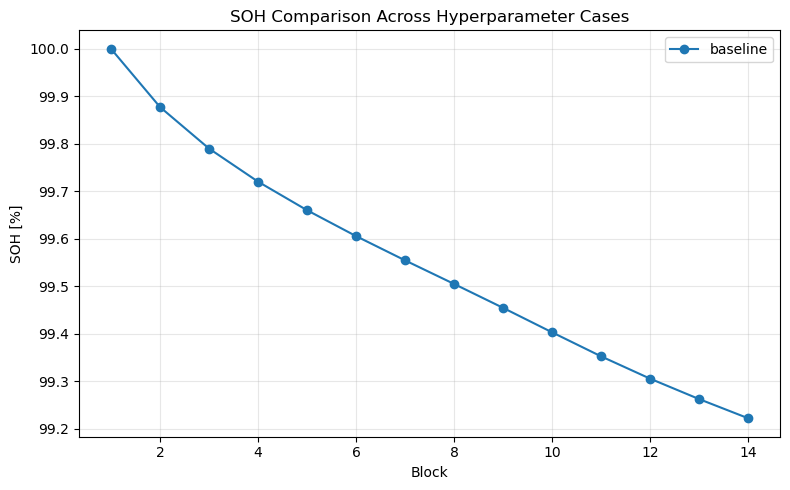

In [11]:
plt.figure(figsize=(8, 5))
for case_name, group in multi_case_summary.groupby("case"):
    plt.plot(group["checkpoint"], group["soh_pct"], "o-", label=case_name)
plt.title("SOH Comparison Across Hyperparameter Cases")
plt.xlabel("Block")
plt.ylabel("SOH [%]")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()